<a href="https://colab.research.google.com/github/hima-84/cellula-internship/blob/main/water_segmentation_v4_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Water Body Segmentation U-Net (Final Fixed Version)
**Data:** Harmonized Sentinel-2/Landsat `.tif` images + binary `.png` masks  
**Input:** 12-band patches (128×128) | **Output:** Binary water mask (128×128)  
**Fixes applied:** Negative clipping, QA band handling, weighted loss, lr=1e-3

---
##  Step 1 — Install & Import

In [1]:
!pip install -q rasterio tifffile scikit-learn

import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm
from sklearn.metrics import jaccard_score, f1_score, precision_score, recall_score

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Device: {DEVICE}')
if DEVICE == 'cpu':
    print('⚠️  No GPU! Go to Runtime → Change runtime type → GPU')

✅ Device: cuda


---
##  Step 2 — Mount Google Drive & Set Paths

In [23]:
from google.colab import drive
drive.mount('/content/drive')

IMAGES_DIR = '/content/drive/MyDrive/Satellite Image/data/images'
LABELS_DIR = '/content/drive/MyDrive/Satellite Image/data/labels'

# If path above doesn't work, uncomment this to find your folder:
# print(os.listdir('/content/drive/MyDrive/'))

img_files = sorted([f for f in os.listdir(IMAGES_DIR) if f.endswith(('.tif', '.tiff'))])
lbl_files = sorted([f for f in os.listdir(LABELS_DIR) if f.endswith('.png')])

print(f' TIF images : {len(img_files)}')
print(f' PNG labels : {len(lbl_files)}')
print(f'   Sample image : {img_files[0]}')
print(f'   Sample label : {lbl_files[0]}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 TIF images : 306
 PNG labels : 456
   Sample image : 0.tif
   Sample label : 0.png


---
##  Step 3 — Inspect One File & Auto-Detect Label Scale

In [3]:
# Check TIFF
with rasterio.open(os.path.join(IMAGES_DIR, img_files[0])) as src:
    print(f'Bands          : {src.count}       ← should be 12')
    print(f'Height x Width : {src.height} x {src.width}  ← should be 128 x 128')
    print(f'Data type      : {src.dtypes[0]}')
    img_sample = src.read().astype(np.float32)

print(f'Value range    : [{img_sample.min():.2f}, {img_sample.max():.2f}]')
print(f'Has NaN        : {np.isnan(img_sample).any()}')

# Check label
lbl_sample  = np.array(Image.open(os.path.join(LABELS_DIR, lbl_files[0])))
unique_vals = np.unique(lbl_sample)
print(f'\nLabel unique values : {unique_vals}')

# Auto-detect label scale
LABEL_SCALE = 255 if 255 in unique_vals else 1
print(f'Label scale set to  : {LABEL_SCALE}  ({"dividing by 255" if LABEL_SCALE==255 else "already binary"})')

Bands          : 12       ← should be 12
Height x Width : 128 x 128  ← should be 128 x 128
Data type      : int16
Value range    : [-28.00, 4975.00]
Has NaN        : False

Label unique values : [0 1]
Label scale set to  : 1  (already binary)


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


---
##  Step 4 — Visualize All 12 Bands + Label

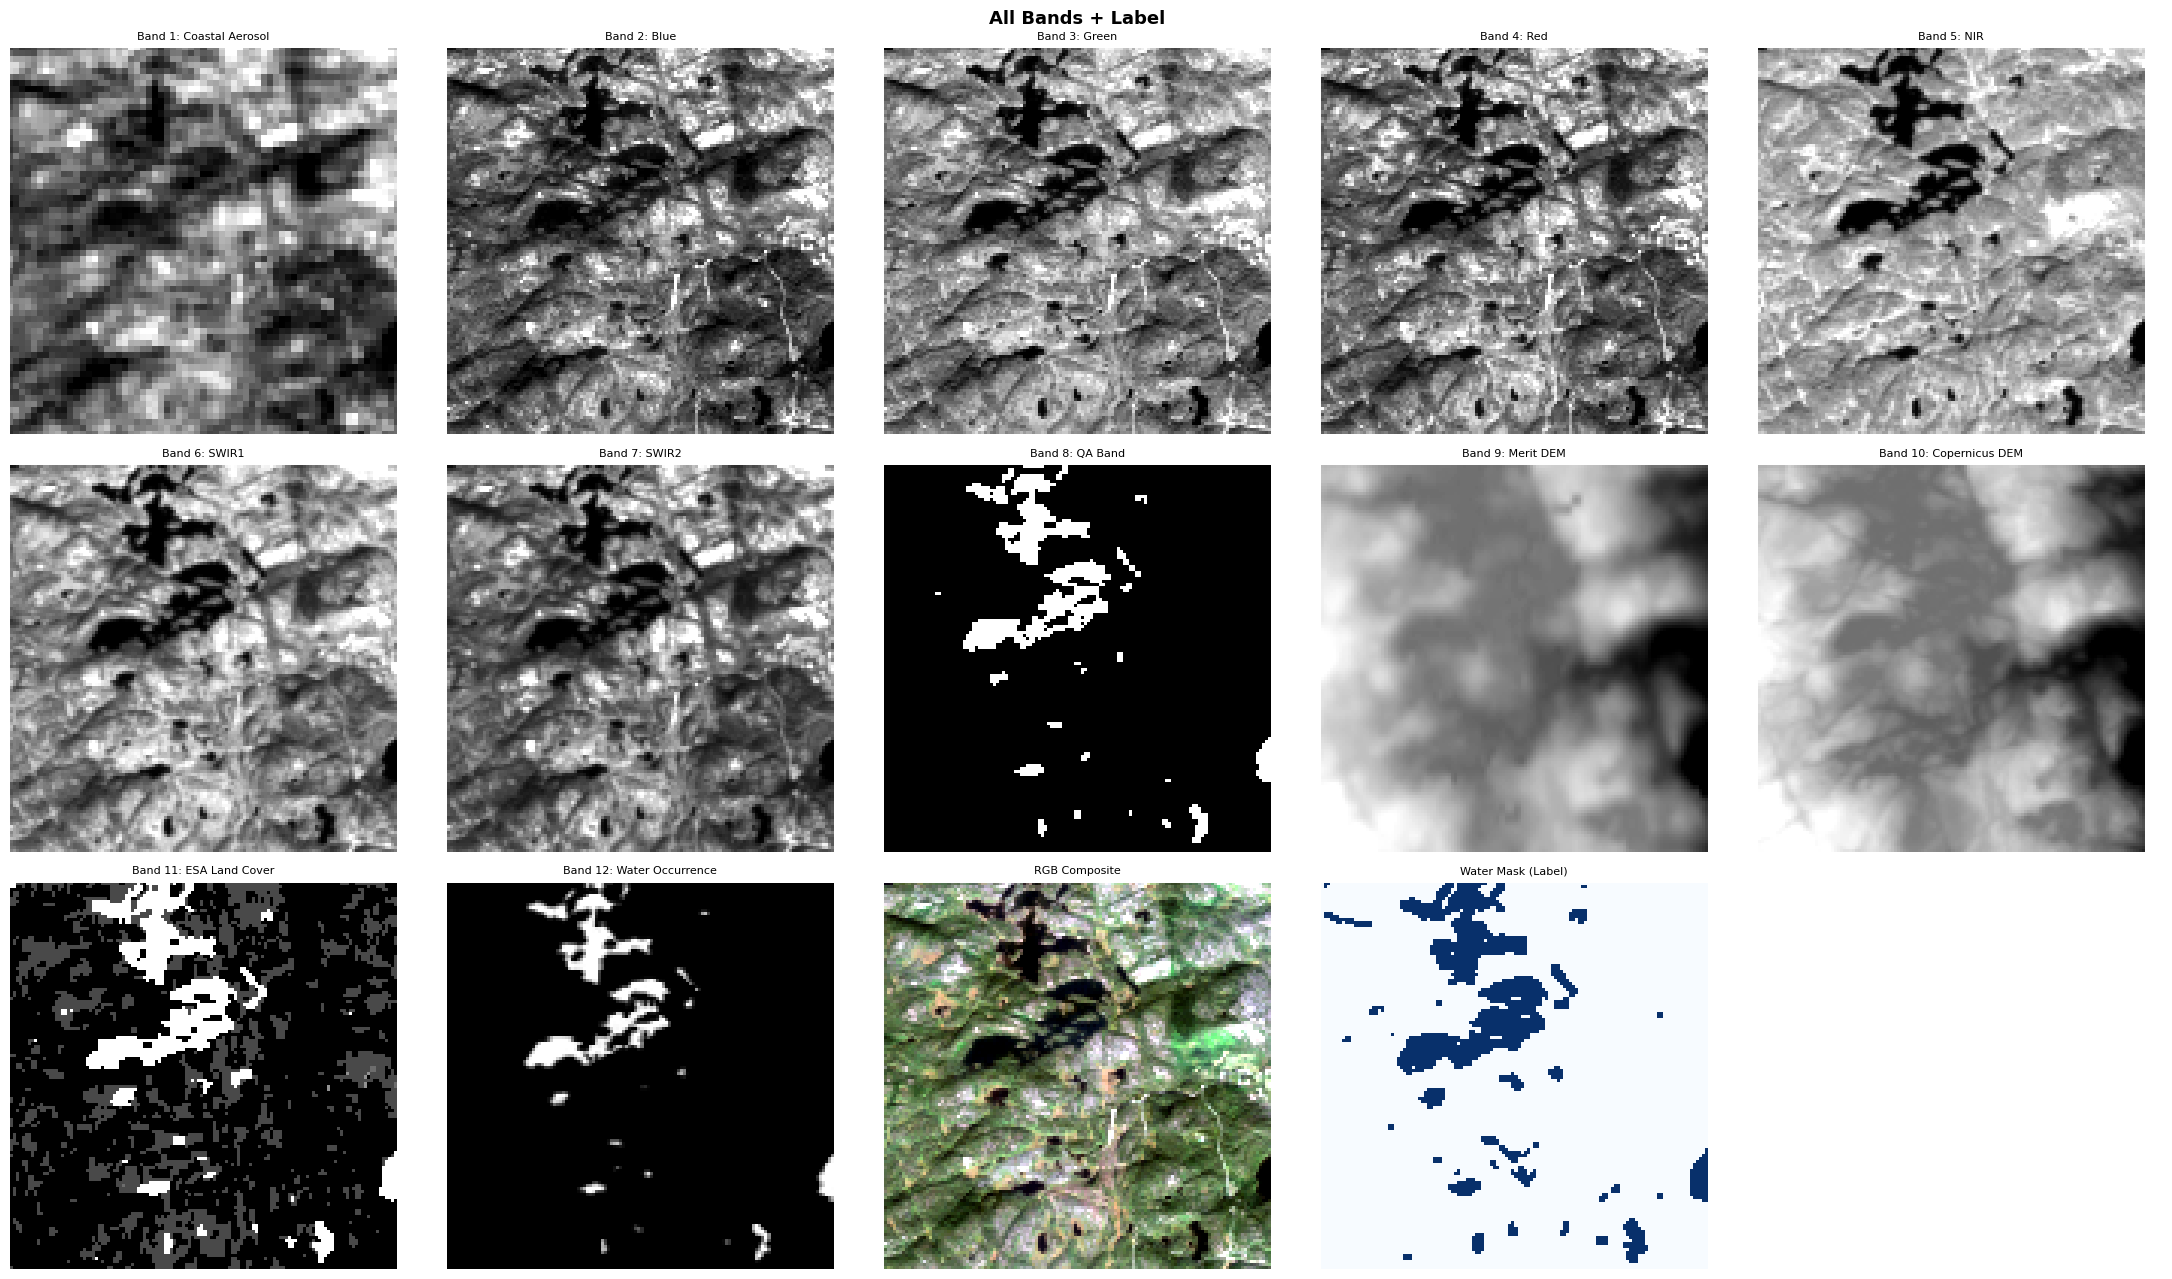

In [4]:
BAND_NAMES = [
    'Coastal Aerosol', 'Blue', 'Green', 'Red',
    'NIR', 'SWIR1', 'SWIR2', 'QA Band',
    'Merit DEM', 'Copernicus DEM', 'ESA Land Cover', 'Water Occurrence'
]

def make_rgb(img, r=3, g=2, b=1):
    rgb = np.stack([img[r], img[g], img[b]], axis=-1).astype(np.float32)
    for c in range(3):
        lo = np.percentile(rgb[:,:,c], 2)
        hi = np.percentile(rgb[:,:,c], 98)
        rgb[:,:,c] = np.clip((rgb[:,:,c] - lo) / (hi - lo + 1e-6), 0, 1)
    return rgb

lbl_vis = np.array(Image.open(os.path.join(LABELS_DIR, lbl_files[0]))) / LABEL_SCALE

fig, axes = plt.subplots(3, 5, figsize=(22, 13))
axes = axes.flatten()

for i in range(12):
    band = img_sample[i].astype(np.float32)
    vmin, vmax = np.percentile(band, 2), np.percentile(band, 98)
    axes[i].imshow(band, cmap='gray', vmin=vmin, vmax=vmax)
    axes[i].set_title(f'Band {i+1}: {BAND_NAMES[i]}', fontsize=8)
    axes[i].axis('off')

axes[12].imshow(make_rgb(img_sample))
axes[12].set_title('RGB Composite', fontsize=8); axes[12].axis('off')

axes[13].imshow(lbl_vis, cmap='Blues', vmin=0, vmax=1)
axes[13].set_title('Water Mask (Label)', fontsize=8); axes[13].axis('off')

axes[14].axis('off')
plt.suptitle('All Bands + Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('band_visualization.png', dpi=100, bbox_inches='tight')
plt.show()

---
##  Step 5 — Load ALL Data (Raw, No Normalization Yet)

In [9]:
# ── Replace your load_dataset function entirely ───────────────

def load_dataset(images_dir, labels_dir, label_scale):
    """
    Matches images and labels strictly by filename stem.
    Skips any file that doesn't have a matching pair.
    """
    img_files = [f for f in os.listdir(images_dir) if f.endswith(('.tif', '.tiff'))]
    lbl_files = [f for f in os.listdir(labels_dir) if f.endswith('.png')]

    # Build lookup dictionaries  {stem → full filename}
    img_dict = {os.path.splitext(f)[0]: f for f in img_files}
    lbl_dict = {os.path.splitext(f)[0]: f for f in lbl_files}

    # Only keep stems that exist in BOTH
    common_stems = sorted(
        img_dict.keys() & lbl_dict.keys(),
        key=lambda x: int(x.split('_')[0])   # numeric sort
    )

    print(f"Images found        : {len(img_dict)}")
    print(f"Labels found        : {len(lbl_dict)}")
    print(f"Matched pairs       : {len(common_stems)}  ← this is your dataset size")
    print(f"Skipped (no match)  : {len(img_dict) - len(common_stems)} images, "
          f"{len(lbl_dict) - len(common_stems)} labels")

    X_list, Y_list = [], []

    for stem in tqdm(common_stems, desc='Loading matched pairs'):
        img_path = os.path.join(images_dir, img_dict[stem])
        lbl_path = os.path.join(labels_dir, lbl_dict[stem])

        with rasterio.open(img_path) as src:
            img = src.read().astype(np.float32)   # (12, 128, 128)

        lbl = np.array(Image.open(lbl_path), dtype=np.float32)
        if lbl.ndim == 3:
            lbl = lbl[:, :, 0]
        lbl = (lbl / label_scale > 0.5).astype(np.float32)

        X_list.append(img)
        Y_list.append(lbl)

    X = np.stack(X_list, axis=0)
    Y = np.stack(Y_list, axis=0)

    print(f"\n✅ Dataset ready")
    print(f"   X : {X.shape}")
    print(f"   Y : {Y.shape}")
    print(f"   Water ratio : {100*Y.mean():.1f}%")
    return X, Y


X_raw, Y = load_dataset(IMAGES_DIR, LABELS_DIR, LABEL_SCALE)

Images found        : 306
Labels found        : 456
Matched pairs       : 306  ← this is your dataset size
Skipped (no match)  : 0 images, 150 labels


Loading matched pairs: 100%|██████████| 306/306 [00:04<00:00, 75.34it/s]



✅ Dataset ready
   X : (306, 12, 128, 128)
   Y : (306, 128, 128)
   Water ratio : 26.0%


In [5]:
# def load_dataset(images_dir, labels_dir, label_scale):
#     img_files = sorted([f for f in os.listdir(images_dir) if f.endswith(('.tif', '.tiff'))])
#     lbl_files = sorted([f for f in os.listdir(labels_dir) if f.endswith('.png')])

#     img_stems = [os.path.splitext(f)[0] for f in img_files]
#     lbl_stems = [os.path.splitext(f)[0] for f in lbl_files]
#     if img_stems != lbl_stems:
#         print(' Filenames dont match — pairing by sorted order')
#         n = min(len(img_files), len(lbl_files))
#         img_files, lbl_files = img_files[:n], lbl_files[:n]

#     X_list, Y_list = [], []
#     for img_f, lbl_f in tqdm(zip(img_files, lbl_files), total=len(img_files), desc='Loading'):
#         with rasterio.open(os.path.join(images_dir, img_f)) as src:
#             img = src.read().astype(np.float32)    # (12, 128, 128)

#         lbl = np.array(Image.open(os.path.join(labels_dir, lbl_f)), dtype=np.float32)
#         if lbl.ndim == 3:
#             lbl = lbl[:, :, 0]
#         lbl = (lbl / label_scale > 0.5).astype(np.float32)

#         X_list.append(img)
#         Y_list.append(lbl)

#     X = np.stack(X_list, axis=0)    # (N, 12, 128, 128)
#     Y = np.stack(Y_list, axis=0)    # (N, 128, 128)

#     print(f'\n Loaded {len(X)} samples')
#     print(f'   X : {X.shape}  |  Y : {Y.shape}')
#     print(f'   Water pixel ratio : {100*Y.mean():.1f}%')
#     return X, Y

# X_raw, Y = load_dataset(IMAGES_DIR, LABELS_DIR, LABEL_SCALE)

⚠️  Filenames dont match — pairing by sorted order


Loading: 100%|██████████| 306/306 [00:10<00:00, 28.35it/s]



✅ Loaded 306 samples
   X : (306, 12, 128, 128)  |  Y : (306, 128, 128)
   Water pixel ratio : 31.4%


---
##  Step 6 — Normalize (Fixed: clip negatives + handle QA band)

In [10]:
def normalize_bands(X, band_names):
    """
    Fixes applied vs naive normalization:
      - Clips negative values (atmospheric correction artifacts in bands 2 & 3)
      - Band 8 (index 7) is a QA bit-flag — scaled by known flag range [64, 160]
      - All bands clipped to [0, 1] after scaling
    """
    X_norm = np.zeros_like(X, dtype=np.float32)
    print(f'{"Band":<5} {"Name":<22} {"Min":>10} {"Max":>10}')
    print('-' * 55)

    for b in range(X.shape[1]):
        band = X[:, b, :, :].copy()

        # Band 8 (index 7) = QA flag, not spectral — scale by known values
        if b == 7:
            band = (band - 64) / (160 - 64 + 1e-6)
            X_norm[:, b, :, :] = np.clip(band, 0, 1)
            print(f'{b+1:<5} {band_names[b]:<22} {"QA flag — fixed range [64,160]"}')
            continue

        # Clip negatives (atmospheric correction artifacts)
        band = np.clip(band, 0, None)

        b_min = band.min()
        b_max = band.max()
        print(f'{b+1:<5} {band_names[b]:<22} {b_min:>10.1f} {b_max:>10.1f}')

        if b_max - b_min > 1e-6:
            X_norm[:, b, :, :] = (band - b_min) / (b_max - b_min)

    return X_norm

X = normalize_bands(X_raw, BAND_NAMES)

# Final safety checks
X = np.clip(X, 0, 1)
X = np.nan_to_num(X, nan=0.0, posinf=1.0, neginf=0.0)

print(f'\nAfter normalization → min:{X.min():.3f}  max:{X.max():.3f}  '
      f'NaN:{np.isnan(X).any()}  Negative:{(X < 0).any()}')

Band  Name                          Min        Max
-------------------------------------------------------
1     Coastal Aerosol               0.0     6568.0
2     Blue                          0.0     9659.0
3     Green                         0.0    11368.0
4     Red                           0.0    12041.0
5     NIR                           0.0    15841.0
6     SWIR1                         0.0    15252.0
7     SWIR2                         0.0    14647.0
8     QA Band                QA flag — fixed range [64,160]
9     Merit DEM                     0.0     4245.0
10    Copernicus DEM                8.0     4287.0
11    ESA Land Cover               10.0      100.0
12    Water Occurrence              0.0      111.0

After normalization → min:0.000  max:1.000  NaN:False  Negative:False


In [11]:
# # ── Check if images and labels are actually paired correctly ──

# img_files = sorted([f for f in os.listdir(IMAGES_DIR) if f.endswith(('.tif', '.tiff'))])
# lbl_files = sorted([f for f in os.listdir(LABELS_DIR) if f.endswith('.png')])

# print("=== FIRST 15 PAIRS ===")
# print(f"{'Image':<30} {'Label':<30} {'Match?'}")
# print('-' * 70)
# for img, lbl in zip(img_files[:15], lbl_files[:15]):
#     img_stem = os.path.splitext(img)[0]
#     lbl_stem = os.path.splitext(lbl)[0]
#     match = '✅' if img_stem == lbl_stem else '❌ MISMATCH'
#     print(f"{img:<30} {lbl:<30} {match}")

# print(f"\nTotal images : {len(img_files)}")
# print(f"Total labels : {len(lbl_files)}")

# # Show the problem — string sorting puts 10 before 2
# print("\n=== SORTING PROBLEM DEMO ===")
# print("String sort:  ", sorted(['10', '2', '1', '20', '3'])[:8])
# print("Correct sort: ", sorted(['10', '2', '1', '20', '3'], key=lambda x: int(x.split('_')[0]))[:8])


=== FIRST 15 PAIRS ===
Image                          Label                          Match?
----------------------------------------------------------------------
0.tif                          0.png                          ✅
1.tif                          1.png                          ✅
10.tif                         10.png                         ✅
100.tif                        100.png                        ✅
101.tif                        100_184.png                    ❌ MISMATCH
102.tif                        101.png                        ❌ MISMATCH
103.tif                        101_89.png                     ❌ MISMATCH
104.tif                        102.png                        ❌ MISMATCH
105.tif                        102_179.png                    ❌ MISMATCH
106.tif                        103.png                        ❌ MISMATCH
107.tif                        103_225.png                    ❌ MISMATCH
108.tif                        104.png                        ❌ MISMAT

---
##  Step 7 — Calculate pos_weight for Imbalanced Classes

In [13]:
# Measure water % across all labels
water_pcts = []
for f in lbl_files:
    l = np.array(Image.open(os.path.join(LABELS_DIR, f)))
    water_pcts.append((l > 0).mean())

avg_water        = np.mean(water_pcts)
pos_weight_value = (1 - avg_water) / avg_water

print(f'Average water %  : {100*avg_water:.2f}%')
print(f'Samples with 0%  : {sum(p==0 for p in water_pcts)}')
print(f'Total samples    : {len(water_pcts)}')
print(f'\npos_weight       : {pos_weight_value:.2f}')
print('(this value tells BCE how much harder to penalize missing water)')

Average water %  : 33.67%
Samples with 0%  : 45
Total samples    : 456

pos_weight       : 1.97
(this value tells BCE how much harder to penalize missing water)


---
## Step 8 — Dataset & DataLoaders

In [14]:
# class WaterDataset(Dataset):
#     def __init__(self, X, Y):
#         self.X = torch.tensor(X, dtype=torch.float32)               # (N, 12, 128, 128)
#         self.Y = torch.tensor(Y, dtype=torch.float32).unsqueeze(1)  # (N, 1, 128, 128)
#     def __len__(self): return len(self.X)
#     def __getitem__(self, idx): return self.X[idx], self.Y[idx]

# dataset    = WaterDataset(X, Y)
# train_size = int(0.8 * len(dataset))
# val_size   = len(dataset) - train_size

# train_ds, val_ds = random_split(
#     dataset, [train_size, val_size],
#     generator=torch.Generator().manual_seed(42)
# )

# train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
# val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

# print(f'Train : {len(train_ds)} samples')
# print(f'Val   : {len(val_ds)} samples')

# # Sanity check
# X_b, Y_b = next(iter(train_loader))
# print(f'Batch X : {X_b.shape}  ← (8, 12, 128, 128)')
# print(f'Batch Y : {Y_b.shape}  ← (8, 1, 128, 128)')



# ── STEP 8 REPLACEMENT — Dataset with Augmentation ──────────
import torchvision.transforms.functional as TF
import random

class WaterDataset(Dataset):
    def __init__(self, X, Y, augment=False):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.Y       = torch.tensor(Y, dtype=torch.float32).unsqueeze(1)
        self.augment = augment

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]   # (12, 128, 128)
        y = self.Y[idx]   # (1,  128, 128)

        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                x = TF.hflip(x)
                y = TF.hflip(y)
            # Random vertical flip
            if random.random() > 0.5:
                x = TF.vflip(x)
                y = TF.vflip(y)
            # Random 90° rotation
            k = random.randint(0, 3)
            if k > 0:
                x = torch.rot90(x, k, dims=[1, 2])
                y = torch.rot90(y, k, dims=[1, 2])

        return x, y


# augment=True only for training, not validation
full_dataset = WaterDataset(X, Y, augment=False)
train_size   = int(0.8 * len(full_dataset))
val_size     = len(full_dataset) - train_size

# Split indices
train_indices, val_indices = torch.utils.data.random_split(
    range(len(full_dataset)), [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_ds = WaterDataset(X[list(train_indices.indices)],
                        Y[list(train_indices.indices)], augment=True)
val_ds   = WaterDataset(X[list(val_indices.indices)],
                        Y[list(val_indices.indices)],   augment=False)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train : {len(train_ds)} samples (with augmentation ✅)')
print(f'Val   : {len(val_ds)} samples')

Train : 244 samples (with augmentation ✅)
Val   : 62 samples


---
## Step 9 — U-Net Model

In [15]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_channels=12, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoders = nn.ModuleList()
        self.pools    = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv(ch, f))
            self.pools.append(nn.MaxPool2d(2))
            ch = f
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        self.upconvs  = nn.ModuleList()
        self.decoders = nn.ModuleList()
        up_ch = features[-1] * 2
        for f in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(up_ch, f, kernel_size=2, stride=2))
            self.decoders.append(DoubleConv(f * 2, f))
            up_ch = f
        self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x); skips.append(x); x = pool(x)
        x = self.bottleneck(x)
        for upconv, dec, skip in zip(self.upconvs, self.decoders, reversed(skips)):
            x = upconv(x)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)
        return self.final(x)   # raw logits


# Verify
model = UNet(in_channels=12, out_channels=1).to(DEVICE)
with torch.no_grad():
    out = model(torch.randn(2, 12, 128, 128).to(DEVICE))
print(f'Output shape : {out.shape}  ← must be (2, 1, 128, 128) ✅')
print(f'Total params : {sum(p.numel() for p in model.parameters()):,}')

Output shape : torch.Size([2, 1, 128, 128])  ← must be (2, 1, 128, 128) ✅
Total params : 31,042,817


---
## Step 10 — Loss, Optimizer & Scheduler (Fixed)

In [18]:
class BCEDiceLoss(nn.Module):
    """
    BCE with pos_weight  — penalizes missing water pixels harder
    Dice                 — handles class imbalance at pixel level
    """
    def __init__(self, pos_weight, smooth=1e-6):
        super().__init__()
        pw           = torch.tensor([pos_weight]).to(DEVICE)
        self.bce     = nn.BCEWithLogitsLoss(pos_weight=pw)
        self.smooth  = smooth

    def dice_loss(self, pred, target):
        pred   = torch.sigmoid(pred).view(-1)
        target = target.view(-1)
        inter  = (pred * target).sum()
        return 1 - (2. * inter + self.smooth) / (pred.sum() + target.sum() + self.smooth)

    def forward(self, pred, target):
        return self.bce(pred, target) + self.dice_loss(pred, target)


# criterion = BCEDiceLoss(pos_weight=pos_weight_value)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', patience=5, factor=0.5
# )

# print(f'Loss       : BCE (pos_weight={pos_weight_value:.2f}) + Dice')
# print(f'Optimizer  : AdamW  lr=1e-3')
# print(f'Scheduler  : ReduceLROnPlateau  patience=5  factor=0.5')


# ── STEP 10 REPLACEMENT — Tuned Loss + Optimizer ────────────
model     = UNet(in_channels=12, out_channels=1).to(DEVICE)  # fresh weights
criterion = BCEDiceLoss(pos_weight=1.5)   # reduced from 1.97 → less aggressive
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

print('✅ Fresh model initialized')
print(f'   pos_weight : 1.5   (was 1.97)')
print(f'   lr         : 5e-4  (was 1e-3)')
print(f'   augment    : flips + 90° rotations on train set')

✅ Fresh model initialized
   pos_weight : 1.5   (was 1.97)
   lr         : 5e-4  (was 1e-3)
   augment    : flips + 90° rotations on train set


---
## Step 11 — Training Loop

In [19]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X_b, Y_b in tqdm(loader, desc='  Train', leave=False):
        X_b, Y_b = X_b.to(DEVICE), Y_b.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_b), Y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []
    for X_b, Y_b in tqdm(loader, desc='  Val  ', leave=False):
        X_b, Y_b = X_b.to(DEVICE), Y_b.to(DEVICE)
        preds      = model(X_b)
        total_loss += criterion(preds, Y_b).item()
        binary = (torch.sigmoid(preds) > 0.5).cpu().numpy().flatten().astype(int)
        target = Y_b.cpu().numpy().flatten().astype(int)
        all_preds.extend(binary)
        all_targets.extend(target)
    iou  = jaccard_score(all_targets, all_preds, zero_division=0)
    f1   = f1_score(all_targets, all_preds, zero_division=0)
    prec = precision_score(all_targets, all_preds, zero_division=0)
    rec  = recall_score(all_targets, all_preds, zero_division=0)
    return total_loss / len(loader), iou, f1, prec, rec


EPOCHS   = 50
best_iou = 0.0
history  = {'train_loss': [], 'val_loss': [], 'iou': [], 'f1': []}

print(f'Training for {EPOCHS} epochs on {DEVICE}...\n')
print(f'{"Epoch":>6} | {"TrainLoss":>10} | {"ValLoss":>9} | {"IoU":>7} | {"F1":>7} | {"Prec":>7} | {"Rec":>7}')
print('-' * 72)

for epoch in range(1, EPOCHS + 1):
    tr_loss                      = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, iou, f1, prec, rec  = validate(model, val_loader, criterion)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['iou'].append(iou)
    history['f1'].append(f1)

    saved = ''
    if iou > best_iou:
        best_iou = iou
        torch.save(model.state_dict(), 'best_unet.pth')
        saved = ' ✅ saved'

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {vl_loss:>9.4f} | '
          f'{iou:>7.4f} | {f1:>7.4f} | {prec:>7.4f} | {rec:>7.4f}{saved}')

print(f'\n Best IoU: {best_iou:.4f}')

Training for 50 epochs on cuda...

 Epoch |  TrainLoss |   ValLoss |     IoU |      F1 |    Prec |     Rec
------------------------------------------------------------------------


     1 |     0.8964 |    0.9526 |  0.5843 |  0.7376 |  0.7189 |  0.7574 ✅ saved


     2 |     0.7438 |    0.7720 |  0.5760 |  0.7310 |  0.8658 |  0.6325


     3 |     0.7028 |    0.7117 |  0.6140 |  0.7609 |  0.9300 |  0.6438 ✅ saved


     4 |     0.6661 |    0.6342 |  0.6440 |  0.7835 |  0.8675 |  0.7143 ✅ saved


...

    46 |     0.4803 |    0.5128 |  0.7051 |  0.8271 |  0.8565 |  0.7995


    47 |     0.4632 |    0.4850 |  0.6867 |  0.8143 |  0.8908 |  0.7499


    48 |     0.4914 |    0.5264 |  0.6920 |  0.8180 |  0.8687 |  0.7728


    49 |     0.4672 |    0.4947 |  0.6865 |  0.8141 |  0.8912 |  0.7493


    50 |     0.5007 |    0.4892 |  0.7015 |  0.8245 |  0.8779 |  0.7773

🏆 Best IoU: 0.7136


---
##  Step 12 — Training Curves

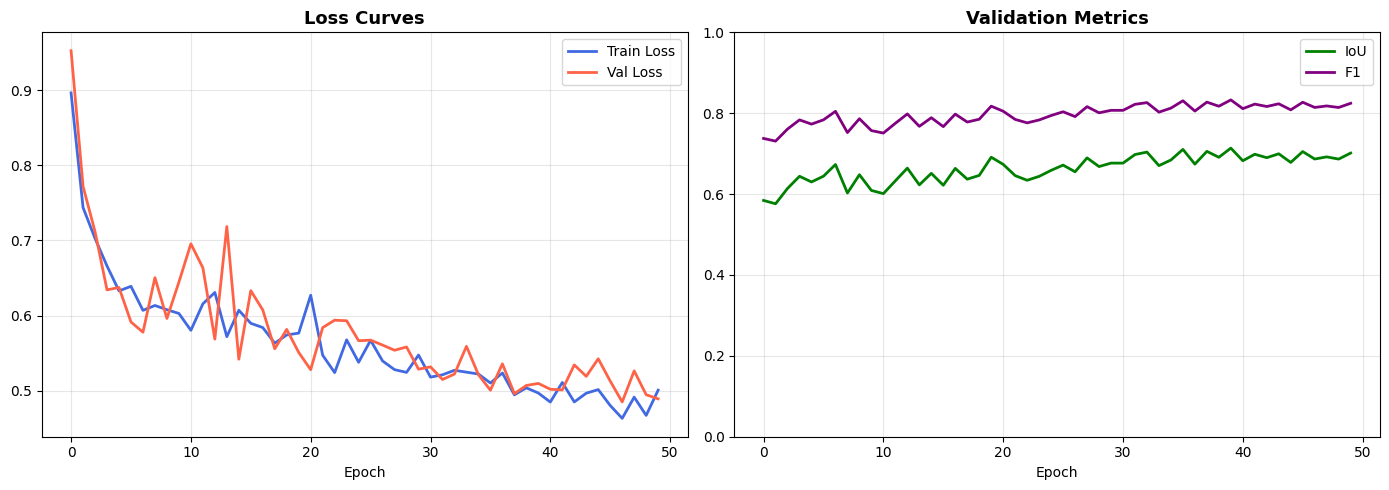

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='royalblue', lw=2)
axes[0].plot(history['val_loss'],   label='Val Loss',   color='tomato',    lw=2)
axes[0].set_title('Loss Curves', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['iou'], label='IoU', color='green',  lw=2)
axes[1].plot(history['f1'],  label='F1',  color='purple', lw=2)
axes[1].set_title('Validation Metrics', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0, 1)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

---
##  Step 13 — Visualize Predictions vs Ground Truth

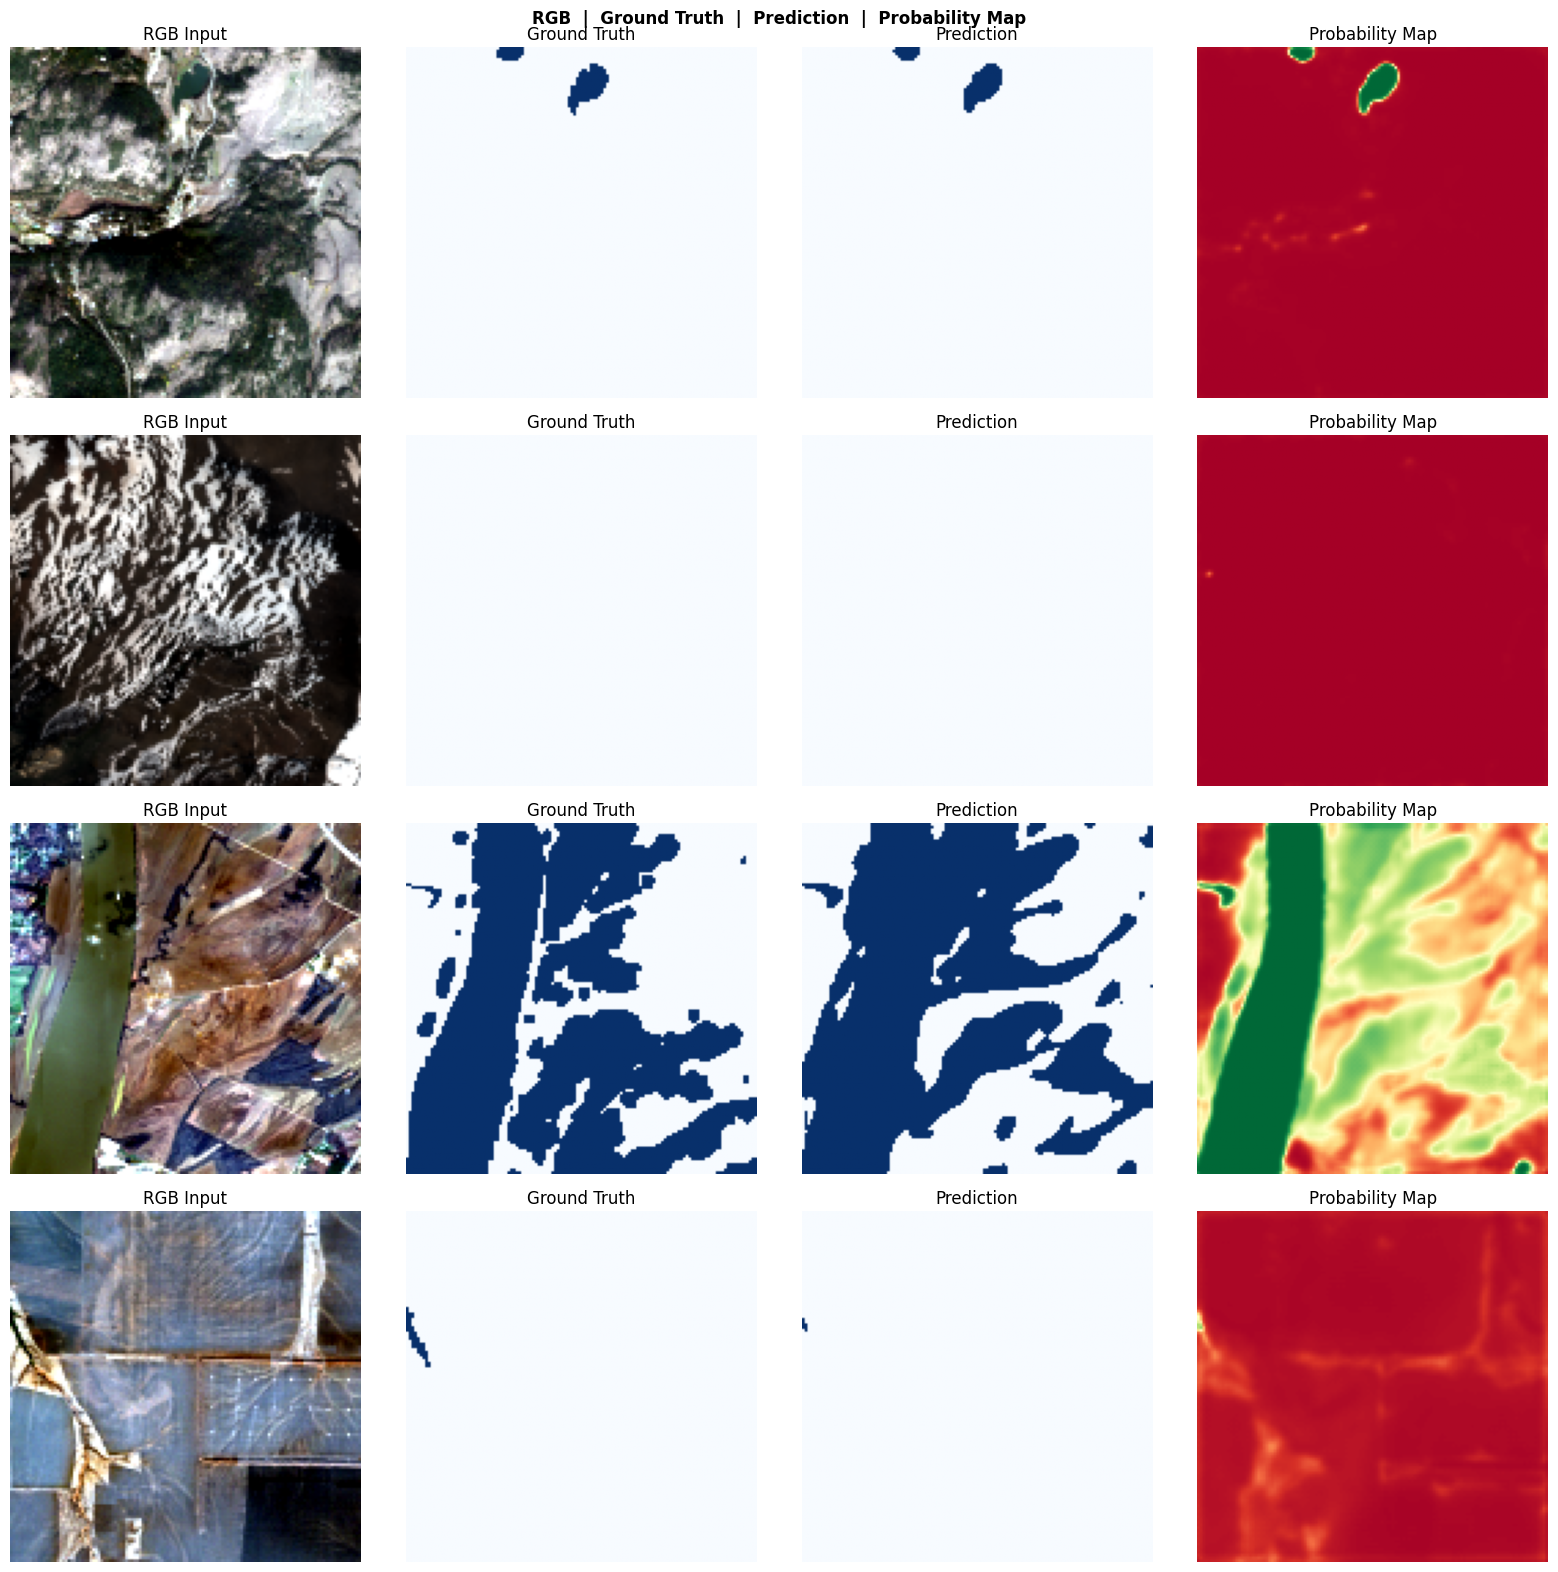

In [21]:
model.load_state_dict(torch.load('best_unet.pth', map_location=DEVICE))
model.eval()

X_vis, Y_vis = next(iter(val_loader))
with torch.no_grad():
    prob_maps  = torch.sigmoid(model(X_vis.to(DEVICE))).cpu().numpy()
    pred_masks = (prob_maps > 0.5).astype(np.float32)

n_show = min(4, len(X_vis))
fig, axes = plt.subplots(n_show, 4, figsize=(16, 4 * n_show))

for i in range(n_show):
    rgb = make_rgb(X_vis[i].numpy())
    axes[i,0].imshow(rgb)
    axes[i,0].set_title('RGB Input');       axes[i,0].axis('off')
    axes[i,1].imshow(Y_vis[i,0], cmap='Blues', vmin=0, vmax=1)
    axes[i,1].set_title('Ground Truth');    axes[i,1].axis('off')
    axes[i,2].imshow(pred_masks[i,0], cmap='Blues', vmin=0, vmax=1)
    axes[i,2].set_title('Prediction');      axes[i,2].axis('off')
    axes[i,3].imshow(prob_maps[i,0], cmap='RdYlGn', vmin=0, vmax=1)
    axes[i,3].set_title('Probability Map'); axes[i,3].axis('off')

plt.suptitle('RGB  |  Ground Truth  |  Prediction  |  Probability Map',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Step 14 — Final Metrics Summary

In [22]:
model.load_state_dict(torch.load('best_unet.pth', map_location=DEVICE))
_, iou, f1, prec, rec = validate(model, val_loader, criterion)

print('=' * 40)
print('      FINAL RESULTS (Best Model)')
print('=' * 40)
print(f'  IoU       : {iou:.4f}  (target > 0.75)')
print(f'  F1 Score  : {f1:.4f}  (target > 0.85)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print('=' * 40)

      FINAL RESULTS (Best Model)
  IoU       : 0.7136  (target > 0.75)
  F1 Score  : 0.8329  (target > 0.85)
  Precision : 0.8668
  Recall    : 0.8016
